# YOLO on Colab Chapter 11 Workshop 4

## Check GPU with CUDA is ready

In [1]:
!nvidia-smi

Tue Jun 10 14:28:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Check GPU with Torch

In [2]:
import torch

# Check if PyTorch is installed
print("PyTorch version:", torch.__version__)

# Check if CUDA (GPU) is available
print("CUDA available:", torch.cuda.is_available())

# If CUDA is available, print details
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU name: Tesla T4
Device count: 1
Current device: 0


## Mouting google drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Path to the drive

In [6]:
ls '/content/drive/MyDrive'

 6-2@                                          MoneyManager/
 6-3@                                          Others/
'A_2375 CU 66.JPG'                            'Roadmap Web Dev.gdoc'
'Ajinomoto Bag POC.gslides'                   'Simple LSTM.gdoc'
 Backup_1105/                                  tax_report_2557_2565.gsheet
'Colab Notebooks'/                            'Test Link.gsheet'
 deep_learning_file/                          'Text Send.gdoc'
'Estimate MEB.gsheet'                         'Weekly Report.gsheet'
'EXP ENG II [ENG] Section 9 [Monday 13-16]'/   Work/
 Finance/                                     'Yokogawa Resume.gdoc'
 Food.gsheet                                  'YTH Tiimesheet 2024.gsheet'
 INVXDLC_20250213_90-2-244751_00.pdf           ข้อสอบ/
 INVXDLC_20250218_90-2-244751_00.pdf           พอร์ต/
'Learning Note'/                              'สำหรับนิสิตปี 1'@


## Create model

In [ ]:
# load model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)



## Use model

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 1080x810 4 persons, 1 bus
Speed: 1098.5ms pre-process, 7.4ms inference, 3.5ms NMS per image at shape (1, 3, 640, 480)


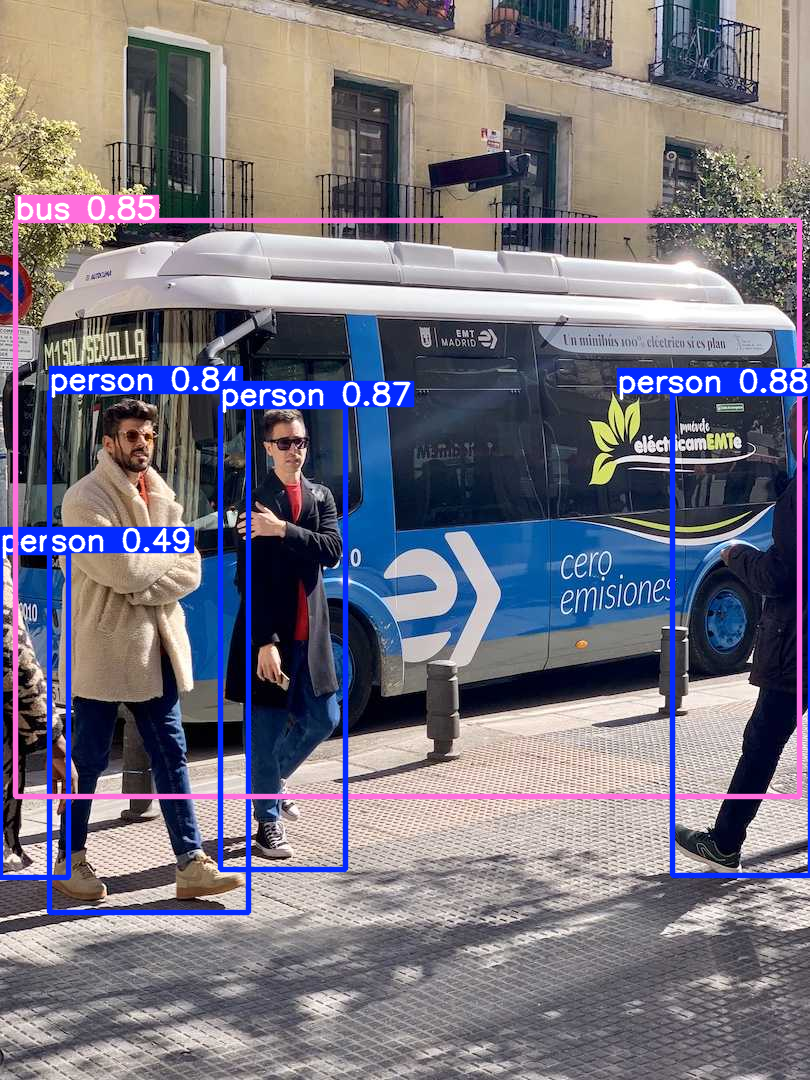

In [13]:
# declare image uri
img_uri = 'https://ultralytics.com/images/bus.jpg'
## img_uri = ['https://web.com/bus.jpg', 'https://web.com/images2.jpg']
## img_uri = Image.open('filename.jpg')


# inference
results = model(img_uri)
results.print()

# show results
results.show()

## show result with dataframe

In [7]:
results.pandas().xyxy[0]

,xmin,ymin,xmax,ymax,confidence,class,name
0,672.296814,393.931641,810.000000,875.515747,0.881810,0,person
1,220.436020,406.628815,345.908203,869.927246,0.866334,0,person
2,15.031692,220.635300,799.227173,796.770691,0.854837,5,bus
3,49.077305,391.318634,248.703506,912.549927,0.841640,0,person
4,0.113570,552.532349,68.449387,877.591431,0.493502,0,person


In [20]:
j = 1
print(results.pandas().xyxy[0][j:j+1].xmin)
print(results.pandas().xyxy[0][j:j+1].ymin)

1    220.43602
Name: xmin, dtype: float64
1    406.628815
Name: ymin, dtype: float64


## Outline Boundary Box

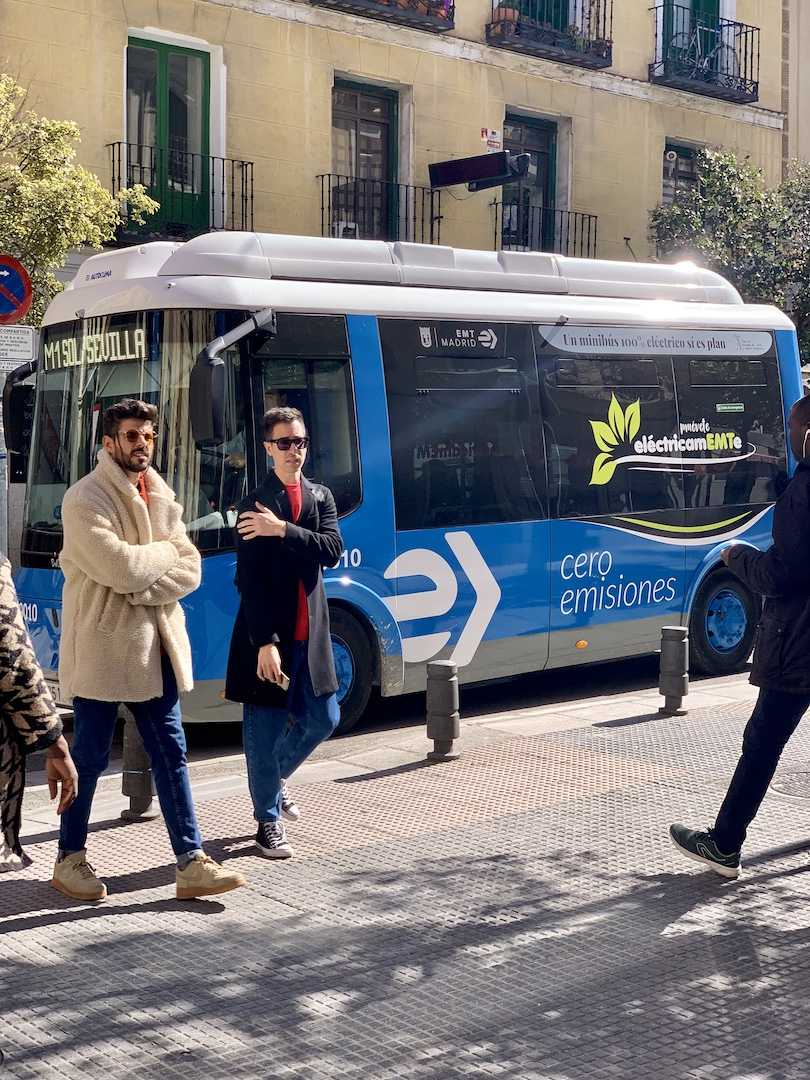

In [8]:
from  urllib.request import urlopen   # load module for requesing data
from PIL import Image                 # load module for handling image
import numpy as np

img = Image.open(urlopen(img_uri))
img

In [24]:
from PIL import Image, ImageFont, ImageDraw
from matplotlib.pyplot import imshow

i = 0
# ค่าพิกัด Coordinate จุดทแยง 2 จุด (ตีกรอบวัตถุ)
p1 = (results.pandas().xyxy[0][i:i+1].xmin, results.pandas().xyxy[0][i:i+1].ymin)
p2 = (results.pandas().xyxy[0][i:i+1].xmax, results.pandas().xyxy[0][i:i+1].ymax)

draw = ImageDraw.Draw(img, "RGBA") # เตรียมเขียนทับภาพ (Overlay)
draw.rectangle((p1,p2), outline=(200,255,200,200), width=8) # draw rectangle

font = ImageFont.truetype('Humor-Sans.ttf', 50) # set font
conf = results.pandas().xyxy[0][i:i+1].confidence[i] # confident value
conf_txt = f" {round(conf*100, 2)}"
label = results.pandas().xyxy[0][i:i+1].name[i] + conf_txt  # label on retangle boundary
draw.text((p1[0]+10,p1[1]), label, font=font, align="left") # draw label

imshow(img)

In [25]:
from PIL import Image, ImageFont, ImageDraw
import matplotlib.pyplot as plt  # Import the library
import numpy as np # Import numpy to convert the PIL image

# Assuming 'results' and 'img' are already defined
# For example:
# img = Image.open("your_image.jpg")
# results = model(img) # Your YOLOv5 or other model results

i = 0

# --- FIX for FutureWarning: Use .iloc[0] ---
# Get the single value from the Pandas Series
xmin = results.pandas().xyxy[0].loc[i, 'xmin']
ymin = results.pandas().xyxy[0].loc[i, 'ymin']
xmax = results.pandas().xyxy[0].loc[i, 'xmax']
ymax = results.pandas().xyxy[0].loc[i, 'ymax']

p1 = (xmin, ymin)
p2 = (xmax, ymax)

draw = ImageDraw.Draw(img, "RGBA")
draw.rectangle((p1, p2), outline=(200, 255, 200, 200), width=8)

# --- FIX for FutureWarning ---
font = ImageFont.truetype('Humor-Sans.ttf', 50) # Make sure this font is uploaded to your Colab environment
conf = results.pandas().xyxy[0].loc[i, 'confidence']
conf_txt = f" {round(conf*100, 2)}%"
label = results.pandas().xyxy[0].loc[i, 'name'] + conf_txt
draw.text((p1[0] + 10, p1[1]), label, font=font, align="left")

# --- FIX to display the image ---
# Convert PIL image to a numpy array for matplotlib
plt.figure(figsize=(12, 12)) # Optional: adjust the figure size
plt.imshow(np.array(img))
plt.axis('off')  # Optional: hide the axes
plt.show()      # Add this line to render the image